# Matemática para Ciencia de los Datos
# Trabajo Práctico 3

Profesor: Juan Luis Crespo Mariño (basado en trabajo previo de Luis Alexánder Calvo Valverde)

Instituto Tecnológico de Costa Rica,

Programa Ciencia de Datos

---

Fecha de entrega: 6 de marzo, hora límite 6:00 pm.

Medio de entrega: Por medio del TEC-Digital.

Entregables: Un archivo jupyter ( .IPYNB ).

Estudiante(s):
1. **Antony Medina**



---

**Pregunta 1**



Se puede demostrar que para los vectores generadores de un subespacio $E=\textrm{espacioGenerado}\left\{ \vec{v}_{1},\vec{v}_{2},\ldots,\vec{v}_{m}\right\}$ , con $V=\left[\vec{v}_{1},\vec{v}_{2},\ldots,\vec{v}_{m}\right]$,con $\vec{v}_{m}\in\mathbb{R}^{n}$ si son ortonormales, la ecuación de la proyección de un vector $\vec{u}\in\mathbb{R}^{n}$ originalmente dada por:

$$\textrm{proy}\left(\vec{u};V\right)=\textrm{argmin}_{\vec{v}\in E}\left\Vert \vec{v}-\vec{u}\right\Vert _{2}=V\,\left(V^{T}V\right)^{-1}V^{T}\vec{u}$$

se puede reescribir como:

$$\textrm{proy}\left(\vec{u};V\right)=\textrm{argmin}_{\vec{v}\in E}\left\Vert \vec{v}-\vec{u}\right\Vert _{2}=V\,V^{T}\vec{u}$$

con $V\in\mathbb{R}^{n\times m}$.









**1.1 (25 puntos)**

Utilizando numpy, proponga una matriz ortonormal de dimensiones 3x3, para ello utilice una fuente como "Proceso de ortonormalización de  Gram - Schmidt" (https://blog.nekomath.com/algebra-lineal-i-proceso-de-gram-schmidt/) para producir una matriz ortonormal a partir de una matriz que no es ni ortonormal ni ortogonal.

Finalmente muestre en numpy que su matriz resultante es ortonormal ($V$).



In [62]:
import numpy as np

def gram_schmidt(A):
    """
    Applies the Gram-Schmidt method to a matrix A with linearly independent 
    columns and returns an orthonormal matrix Q.

    Parameters:
    A (numpy.ndarray): A matrix where each column is an input vector.

    Returns:
    numpy.ndarray: An orthonormal matrix Q.
    """
    # Create a copy of A to store the orthonormal vectors (Q)
    Q = np.array(A, dtype=float)
    # Get the number of columns (vectors)
    n = Q.shape[1]

    for j in range(n):
        # Start with the current vector
        v = Q[:, j]
        
        # Subtract the projection of v onto each of the previous orthonormal vectors
        for i in range(j):
            q_i = Q[:, i]
            # Calculate the projection (dot product)
            proj_scalar = np.dot(v, q_i)
            v = v - proj_scalar * q_i
            
        # Normalize the resulting vector
        norm_v = np.linalg.norm(v)
        
        # Handle cases where vectors are linearly dependent (norm is close to zero)
        if np.isclose(norm_v, 0.0):
            raise ValueError("Input vectors are not linearly independent")
        
        Q[:, j] = v / norm_v
        
    return Q

# --- Example Usage ---
# Input vectors as columns of a matrix
V = np.array([
    [2, 1, 0],
    [0, 3, 1],
    [1, 0, 4]
])

try:
    Q = gram_schmidt(V)
    print("Original Matriz V:\n", V)
    print("\nMatriz Ortonormal Q:\n", Q)
    
    # Verification: Q^T * Q should be close to the identity matrix
    print("\nQ^T * Q:\n", np.dot(Q.T, Q).round(5)) # round to handle floating point errors
except ValueError as e:
    print(e)


Original Matriz V:
 [[2 1 0]
 [0 3 1]
 [1 0 4]]

Matriz Ortonormal Q:
 [[ 0.89442719  0.06593805 -0.44232587]
 [ 0.          0.98907071  0.14744196]
 [ 0.4472136  -0.13187609  0.88465174]]

Q^T * Q:
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]


**1.2 (15 puntos)**

Proponga un vector $\vec{u}$ y programe en numpy las operaciones algebraicas siguientes (tome $V$ del paso anterior).

$V\,\left(V^{T}V\right)^{-1}V^{T}\vec{u}$

y,

$V\,V^{T}\vec{u}$


**1.3 (10 puntos)**

Programe en python para calcular el error de proyección obtenido para los casos del punto **1.2**.

---

**Pregunta 2 (10 puntos)**


Programe en python la función calculeDet2, que recibe como parámetro una matriz cuadrada de dimensiones 2x2, llamada M, y retorna el determinante de esa matriz. Usted debe programar las operaciones matemáticas necesarias, no utilizar una función tipo det para calcularla. Pruébela con dos matrices que Usted proponga.

def calculeDet2( M ):





In [63]:
# Function for finding the determinant of a matrix.
def getDet(mat, n):
  
    # Base case: if the matrix is 1x1
    if n == 1:
        return mat[0][0]
    
    # Base case for 2x2 matrix
    if n == 2:
        return mat[0][0] * mat[1][1] - \
               mat[0][1] * mat[1][0]
    
    # Recursive case for larger matrices
    res = 0
    for col in range(n):
      
        # Create a submatrix by removing the first 
        # row and the current column
        sub = [[0] * (n - 1) for _ in range(n - 1)]
        for i in range(1, n):
            subcol = 0
            for j in range(n):
              
                # Skip the current column
                if j == col:
                    continue
                
                # Fill the submatrix
                sub[i - 1][subcol] = mat[i][j]
                subcol += 1
        
        # Cofactor expansion
        sign = 1 if col % 2 == 0 else -1
        res += sign * mat[0][col] * getDet(sub, n - 1)
    
    return res

# Driver program to test the above function
matA = [[20, 45],
        [10, 15]]

print("El determinante de la matriz es:", getDet(matA, 2))

matB = [[2, 5],
        [1, 3]]
print("El determinante de la matriz es:", getDet(matB, 2))

El determinante de la matriz es: -150
El determinante de la matriz es: 1


---

**Pregunta 3 (10 puntos)**


Programe en python la función calculeDet3, que recibe como parámetro una matriz cuadrada de dimensiones 3x3, llamada M, y retorna el determinante de esa matriz. Usted debe programar las operaciones matemáticas necesarias, no utilizar una función de numpy tipo det para calcularla (sí puede usar función que programó en la **Pregunta 2**). Pruébela con dos matrices que Usted proponga.

def calculeDet3( M ):






In [64]:
matC = [[1, 2, 3],
        [0, 1, 4],
        [5, 6, 0]]
print("El determinante de la matriz es:", getDet(matC, 3))

El determinante de la matriz es: 1


---

**Pregunta 4 (15 puntos)**

Se tiene que:

$$\textrm{det}\left(A\,B\right)=\textrm{det}\left(A\right)\,\textrm{det}\left(B\right)$$

Proponga dos matrices de 4x4 ( $A$ e $B$) y programando en numpy muestre esta igualdad (puede usar de numpy las funciones det y la de multiplicar matrices).






In [65]:
matA_4x4 = np.array([[1,5,9,6],
              [6,8,9,10],
              [9,77,2,1],
              [11,2,3,4]])



matB_4x4 = np.array([[88,1,3,4],
              [8,1,5,12],
              [22,1,4,1],
              [10,1,13,5]])
matAB_4X4_mul = np.matmul(matA_4x4, matB_4x4)
print("Det(AB):", getDet(matAB_4X4_mul, 4))

print("Det(A) * Det(B):", getDet(matA_4x4, 4)*getDet(matB_4x4, 4))

print("Det(AB) == Det(A) * Det(B):", np.isclose(getDet(matAB_4X4_mul, 4), getDet(matA_4x4, 4)*getDet(matB_4x4, 4)))

Det(AB): -148831256
Det(A) * Det(B): -148831256
Det(AB) == Det(A) * Det(B): True


---

**Pregunta 5 (15 puntos)**


Utilizando el archivo "Dataset_usar.csv", haga:
- Cargue el archivo.
- Muestre cuántas filas por cuántas columnas tiene el conjunto de datos.
- Utilizando el modelo $Ax=b$
    - Conforme la matriz $A$ con todas las columnas menos la última de la derecha.
    - Conforme el vector $b$ con la última columna de la derecha.
    - Calcule el vector de pesos ($x$), utilizando el concepto de mínimos cuadrados $\left(A^{T}A\right)^{-1}A^{T}\vec{b}$
    - Calcule un b_estimado con $A$ e $x$
    - Calcule la norma 2 de la diferencia entre b y b_estimado.
    - Grafique b y b_estimado.



   bias    Length  Diameter    Height     Whole   Shucked  Sex_Female  \
0     1  0.186567  0.155963  0.195652  0.011688  0.333333           0   
1     1  0.813433  0.761468  0.826087  0.433327  0.333333           1   
2     1  0.410448  0.376147  0.369565  0.074022  0.333333           1   
3     1  0.537313  0.504587  0.500000  0.143085  0.333333           1   
4     1  0.507463  0.495413  0.565217  0.146981  0.333333           0   

   Sex_Masculine  Shellweight  
0              1        0.010  
1              0        0.435  
2              0        0.068  
3              0        0.096  
4              1        0.144  
El conjunto de datos tiene 998 filas y 9 columnas.
La norma 2 de la diferencia (error total) es: 3.2401


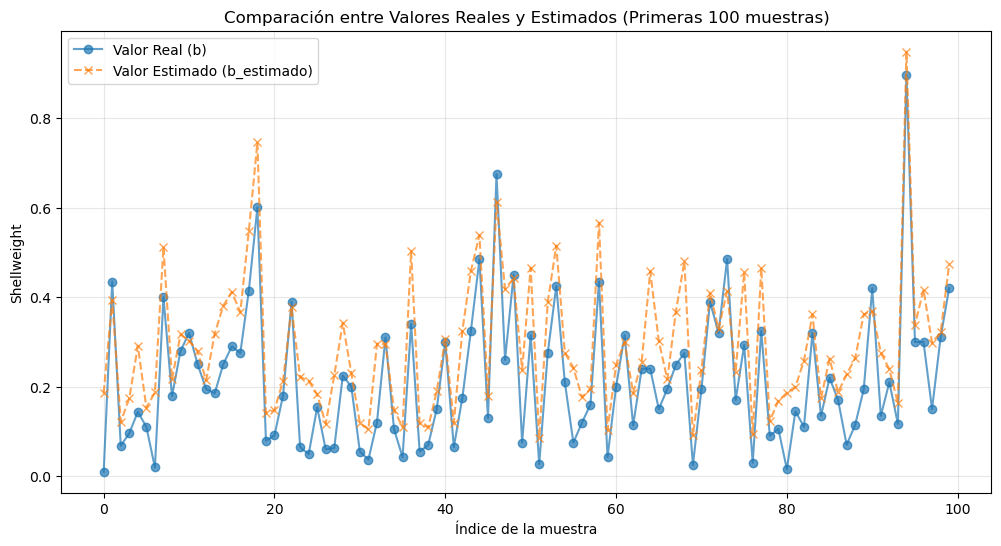

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el archivo
# Asegúrate de que el archivo CSV esté en el mismo directorio que tu script
df = pd.read_csv('Dataset_usar.csv', sep=';', header=0)  # Ajusta el separador si es necesario
print(df.head())  # Muestra las primeras filas para verificar que se cargó correctamente
# 2. Mostrar cuántas filas por cuántas columnas tiene el conjunto de datos
filas, columnas = df.shape
print(f"El conjunto de datos tiene {filas} filas y {columnas} columnas.")

data = df.to_numpy(dtype=np.float64)
# 3. Conformar la matriz A y el vector b
# A: Todas las filas, todas las columnas excepto la última
A = data[:, :-1]

# b: Todas las filas, solo la última columna
b = data[:, -1]


# 4. Calcular el vector de pesos (x) usando mínimos cuadrados
# Ecuación: x = (A^T * A)^-1 * A^T * b
A_T = A.T
x = np.linalg.inv(A_T @ A) @ A_T @ b

# 5. Calcular b_estimado
b_estimado = A @ x

# 6. Calcular la norma 2 de la diferencia
# La norma 2 (Euclidiana) mide la magnitud del error de nuestras estimaciones


diferencia = b - b_estimado
norma_2 = np.linalg.norm(diferencia, 2)
print(f"La norma 2 de la diferencia (error total) es: {norma_2:.4f}")

# 7. Graficar b y b_estimado
plt.figure(figsize=(12, 6))
# Usamos un gráfico de dispersión (scatter) o líneas. 
# Si el dataset es muy grande, visualizar solo los primeros 100 puntos ayuda a la claridad.
plt.plot(b[:100], label='Valor Real (b)', marker='o', linestyle='-', alpha=0.7)
plt.plot(b_estimado[:100], label='Valor Estimado (b_estimado)', marker='x', linestyle='--', alpha=0.7)

plt.title('Comparación entre Valores Reales y Estimados (Primeras 100 muestras)')
plt.xlabel('Índice de la muestra')
plt.ylabel('Shellweight')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()